In [157]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# DATASET1 (Healthcare attrition)

In [158]:
df=pd.read_csv('EmployeeArt/watson_healthcare_modified.csv')
df=df.drop(columns=["EmployeeID"])
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18',
       'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'Shift',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [159]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18',
       'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'Shift',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

## EDA


In [160]:
df.dtypes

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
Shift                        int64
TotalWorkingYears            int64
TrainingTimesLastYea

In [161]:
df.BusinessTravel.value_counts()

BusinessTravel
Travel_Rarely        1184
Travel_Frequently     320
Non-Travel            172
Name: count, dtype: int64

In [162]:
df=df.drop(columns=["Over18","EmployeeCount","StandardHours"])

In [163]:
df.columns.shape

(31,)

In [164]:
col = df["Attrition"]
df = df.drop("Attrition", axis=1)
df["Attrition"] = col

In [165]:
# df.columns

In [166]:

CategoricalCols=np.zeros(len(df.columns))
NumericCols=np.zeros(len(df.columns))

CategoricalColsIndex=[] # index from 0
NumericColsIndex=[]
for i, (col, dtype) in enumerate(zip(df.columns, df.dtypes)):
    if dtype=="object":
        CategoricalCols[i]=1
        CategoricalColsIndex.append(i)
        df[col] = df[col].astype('category')
    else:
        NumericCols[i]=1
        NumericColsIndex.append(i)


In [167]:
df.columns

Index(['Age', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome',
       'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender',
       'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole',
       'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate',
       'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'Shift',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'Attrition'],
      dtype='object')

In [168]:
# NumericCols
# print(NumericColsIndex)

In [169]:
df.Attrition

0        No
1        No
2       Yes
3        No
4        No
       ... 
1671    Yes
1672     No
1673     No
1674     No
1675     No
Name: Attrition, Length: 1676, dtype: category
Categories (2, object): ['No', 'Yes']

In [170]:
df["Attrition"] = df["Attrition"].map({"No": 0, "Yes": 1})


In [176]:
# df.columns
corrmatrix=df.corr(numeric_only=True)
corrmatrix.head(23)

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,PerformanceRating,RelationshipSatisfaction,Shift,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Age,1.000000,0.001441,-0.010079,0.204655,0.008945,0.034671,0.034193,0.518333,-0.015848,0.511378,...,0.005246,0.058528,0.037117,0.692512,-0.015408,-0.004878,0.319012,0.222655,0.217212,0.215909
DailyRate,0.001441,1.000000,-0.009227,-0.015881,0.010620,0.027128,0.058864,0.009005,0.032115,0.011030,...,0.003353,0.014539,0.054407,0.009378,0.001901,-0.028549,-0.026892,0.019651,-0.034571,-0.025272
DistanceFromHome,-0.010079,-0.009227,1.000000,0.015937,-0.019730,0.026947,0.010281,-0.023455,-0.004758,-0.041201,...,0.020482,0.005482,0.029180,-0.017663,-0.055471,-0.037821,-0.007420,0.011448,-0.000126,0.000403
Education,0.204655,-0.015881,0.015937,1.000000,-0.031925,0.017996,0.041046,0.093227,-0.003957,0.085116,...,-0.020664,-0.005750,0.024451,0.143324,-0.014070,0.003933,0.057461,0.051029,0.045785,0.055096
EnvironmentSatisfaction,0.008945,0.010620,-0.019730,-0.031925,1.000000,-0.057505,-0.007220,0.008277,0.001518,0.003372,...,-0.029104,0.003221,0.005283,0.000208,-0.017722,0.027262,-0.000448,0.012241,0.005866,-0.012417
HourlyRate,0.034671,0.027128,0.026947,0.017996,-0.057505,1.000000,0.034741,-0.018830,-0.073942,-0.008443,...,-0.000370,0.000601,0.051862,0.005988,-0.007194,-0.009956,-0.014742,-0.016776,-0.028642,-0.021436
JobInvolvement,0.034193,0.058864,0.010281,0.041046,-0.007220,0.034741,1.000000,-0.013660,-0.039738,-0.019240,...,-0.017970,0.045107,0.025999,-0.001576,-0.031580,-0.006931,-0.013652,0.020541,-0.022153,0.031574
JobLevel,0.518333,0.009005,-0.023455,0.093227,0.008277,-0.018830,-0.013660,1.000000,-0.012497,0.951572,...,-0.008759,0.030606,0.010478,0.780929,-0.004251,0.047481,0.532529,0.387624,0.343102,0.379717
JobSatisfaction,-0.015848,0.032115,-0.004758,-0.003957,0.001518,-0.073942,-0.039738,-0.012497,1.000000,-0.016550,...,0.008859,-0.018232,0.017740,-0.021435,-0.003440,-0.017280,0.005376,-0.001337,-0.013595,-0.023042
MonthlyIncome,0.511378,0.011030,-0.041201,0.085116,0.003372,-0.008443,-0.019240,0.951572,-0.016550,1.000000,...,-0.005113,0.033035,0.005847,0.772938,-0.009690,0.039910,0.513977,0.364152,0.337241,0.350122


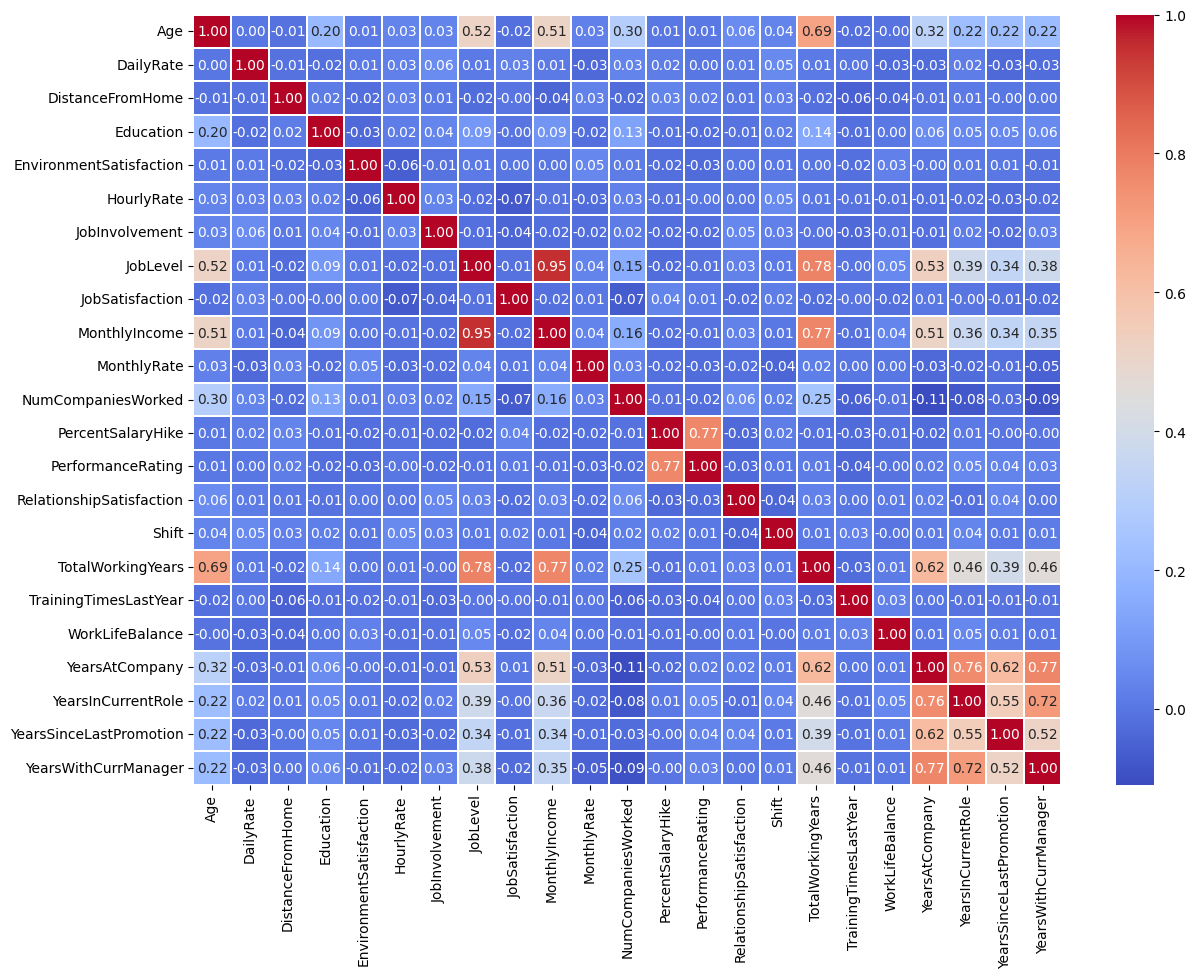

In [172]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))  
sns.heatmap(corrmatrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.1)
plt.show()


In [ ]:
# high corellation between performance rating and salary hike
# job level nad years of working

In [174]:
categorical_df = df.select_dtypes(include=['category'])
categorical_df

,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,OverTime,Attrition
0,Travel_Rarely,Cardiology,Life Sciences,Female,Nurse,Single,Yes,0
1,Travel_Frequently,Maternity,Life Sciences,Male,Other,Married,No,0
2,Travel_Rarely,Maternity,Other,Male,Nurse,Single,Yes,1
3,Travel_Frequently,Maternity,Life Sciences,Female,Other,Married,Yes,0
4,Travel_Rarely,Maternity,Medical,Male,Nurse,Married,No,0
...,...,...,...,...,...,...,...,...
1671,Travel_Rarely,Neurology,Technical Degree,Male,Nurse,Single,Yes,1
1672,Travel_Rarely,Cardiology,Marketing,Female,Nurse,Married,Yes,0
1673,Travel_Rarely,Maternity,Life Sciences,Female,Other,Single,No,0
1674,Travel_Rarely,Neurology,Life Sciences,Female,Therapist,Married,No,0


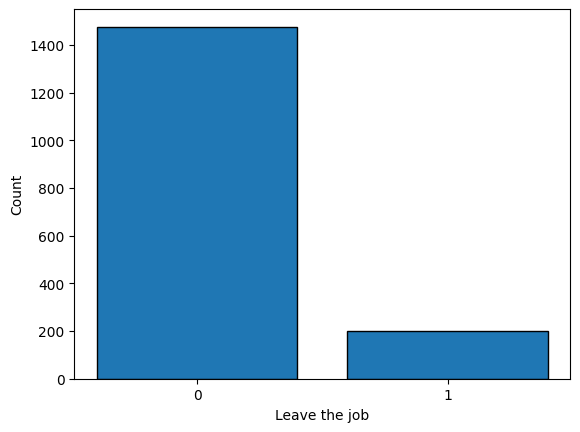

In [178]:
counts = df["Attrition"].value_counts().sort_index()

plt.bar(counts.index, counts.values, edgecolor='black')
plt.xticks(counts.index) # imp
plt.xlabel("Leave the job")
plt.ylabel("Count")
plt.show()

In [ ]:
non_categorical_cols = df.select_dtypes(include=['number']).columns

23

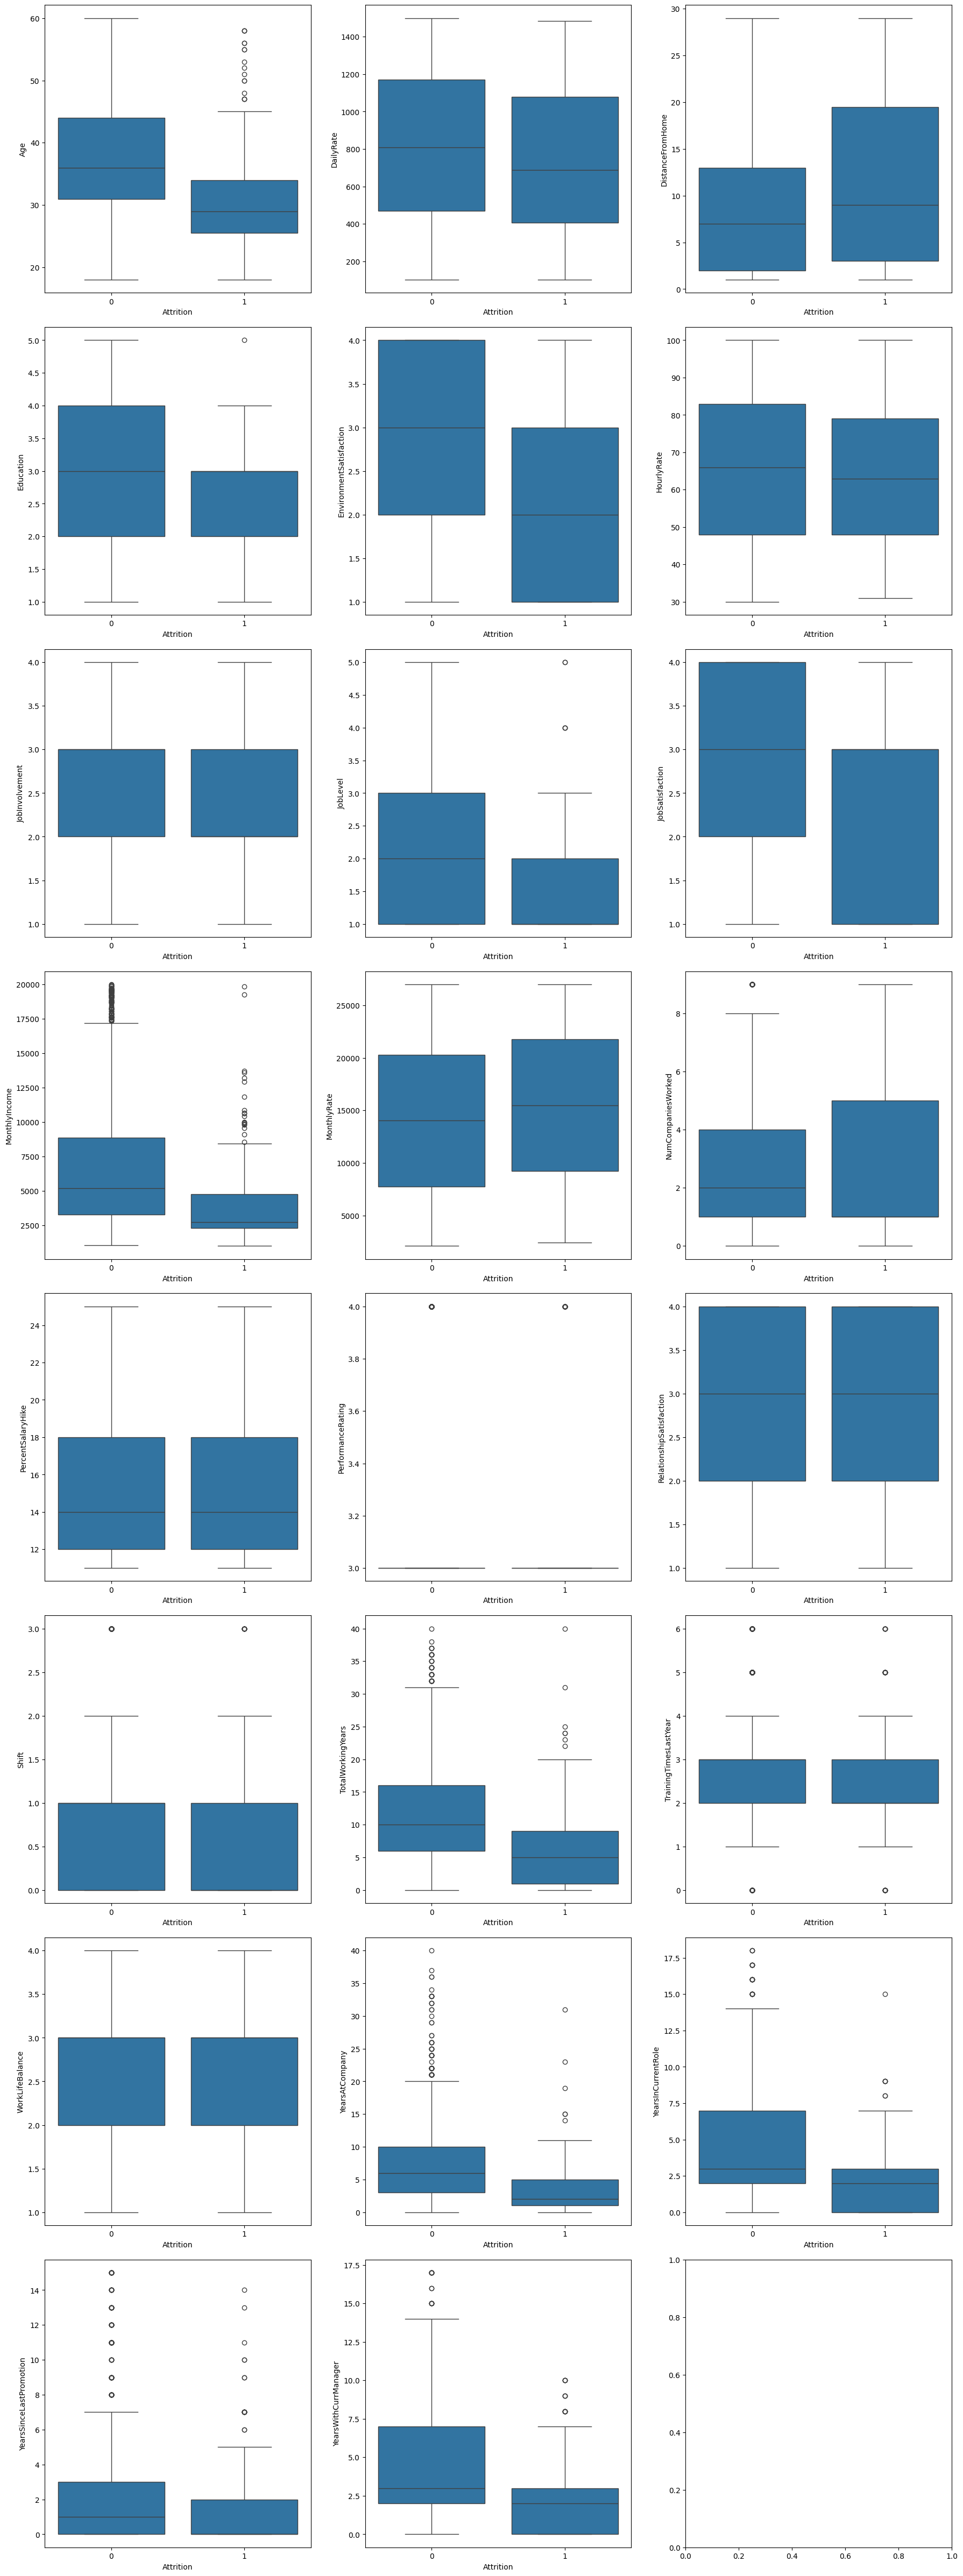

In [182]:
import math

total_plots = len(non_categorical_cols) 
cols = 3
rows = math.ceil(total_plots / cols)

fig_width = cols * 6
fig_height = rows * 6

fig, axes = plt.subplots(
    nrows=rows,
    ncols=cols,
    figsize=(fig_width, fig_height),
    # constrained_layout=True
)
row,col=0,0
for i in df.columns:
    if df[i].dtype!="category":
        sns.boxplot(ax=axes[row,col],x=df['Attrition'],y=df[i])
        col=col+1
        if(col==3):
            row+=1
        col=(col)%cols

plt.tight_layout(w_pad=2)
plt.show()

In [187]:
df.dtypes

Age                            int64
BusinessTravel              category
DailyRate                      int64
Department                  category
DistanceFromHome               int64
Education                      int64
EducationField              category
EnvironmentSatisfaction        int64
Gender                      category
HourlyRate                     int64
JobInvolvement                 int64
JobLevel                       int64
JobRole                     category
JobSatisfaction                int64
MaritalStatus               category
MonthlyIncome                  int64
MonthlyRate                    int64
NumCompaniesWorked             int64
OverTime                    category
PercentSalaryHike              int64
PerformanceRating              int64
RelationshipSatisfaction       int64
Shift                          int64
TotalWorkingYears              int64
TrainingTimesLastYear          int64
WorkLifeBalance                int64
YearsAtCompany                 int64
Y

In [ ]:
df[""].value_counts()

JobInvolvement
3    983
2    433
4    164
1     96
Name: count, dtype: int64

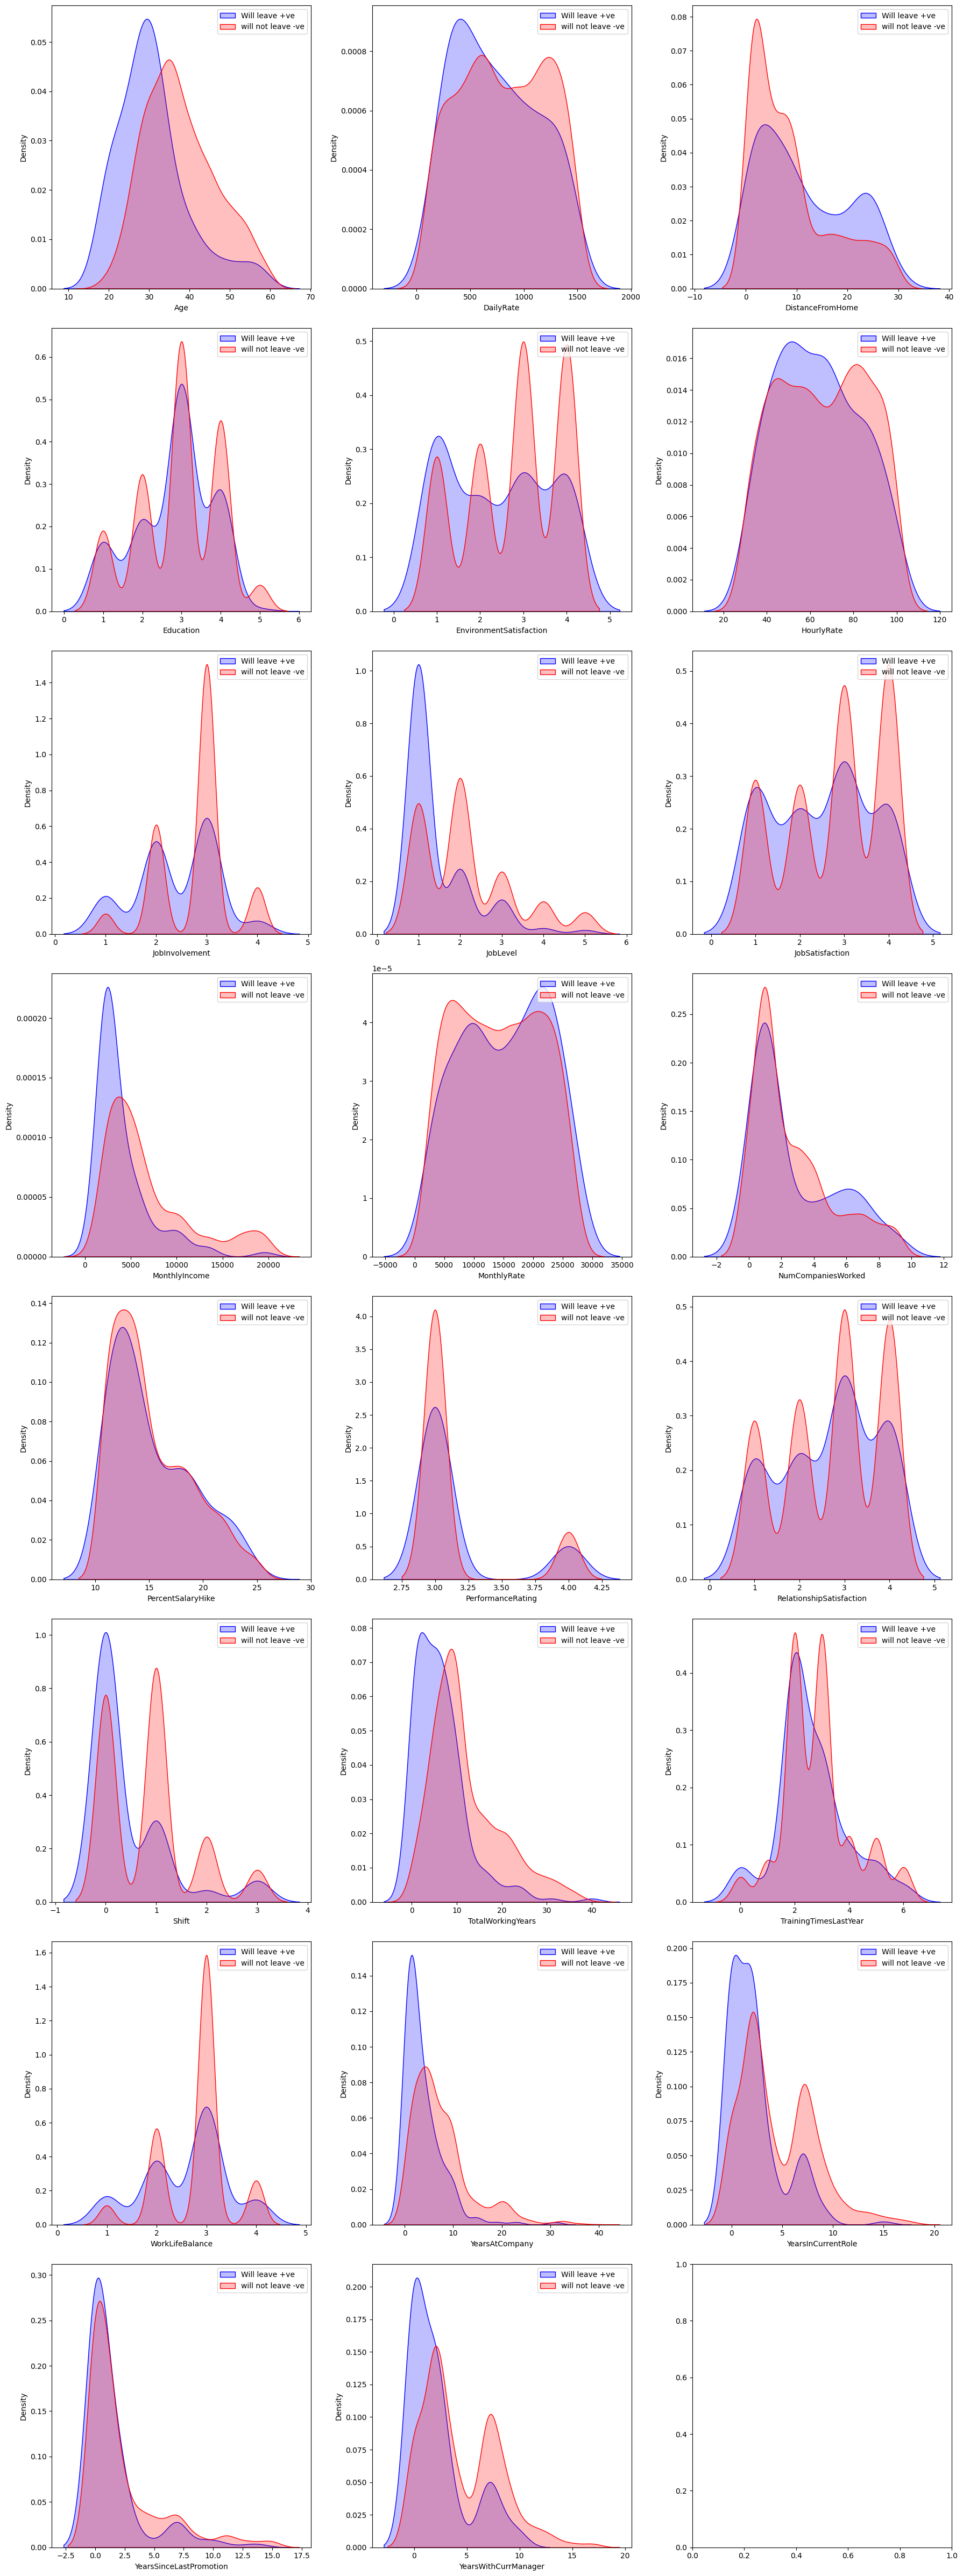

In [191]:

total_plots = len(non_categorical_cols) 
cols = 3
rows = math.ceil(total_plots / cols)

fig_width = cols * 6
fig_height = rows * 6

fig, axes = plt.subplots(
    nrows=rows,
    ncols=cols,
    figsize=(fig_width, fig_height),
    # constrained_layout=True
)
row,col=0,0

for i in df.columns:
    if df[i].dtype!="category":
        
        sns.kdeplot(
            df[df["Attrition"]==1][i],
            color='blue', label='Will leave +ve',
            ax=axes[row,col],
            fill=True
            )
        
        sns.kdeplot(
            df[df["Attrition"]==0][i],
            color='red', 
            label='will not leave -ve',
            ax=axes[row,col],
            fill=True
            )
        
        axes[row, col].legend()
        col=col+1
        if(col==3):
            row+=1
        col=(col)%cols

plt.tight_layout(w_pad=2)
plt.show()





DailyRate
1329    7
691     7
715     6
1082    6
530     6
       ..
1037    1
1382    1
161     1
642     1
1321    1
Name: count, Length: 886, dtype: int64

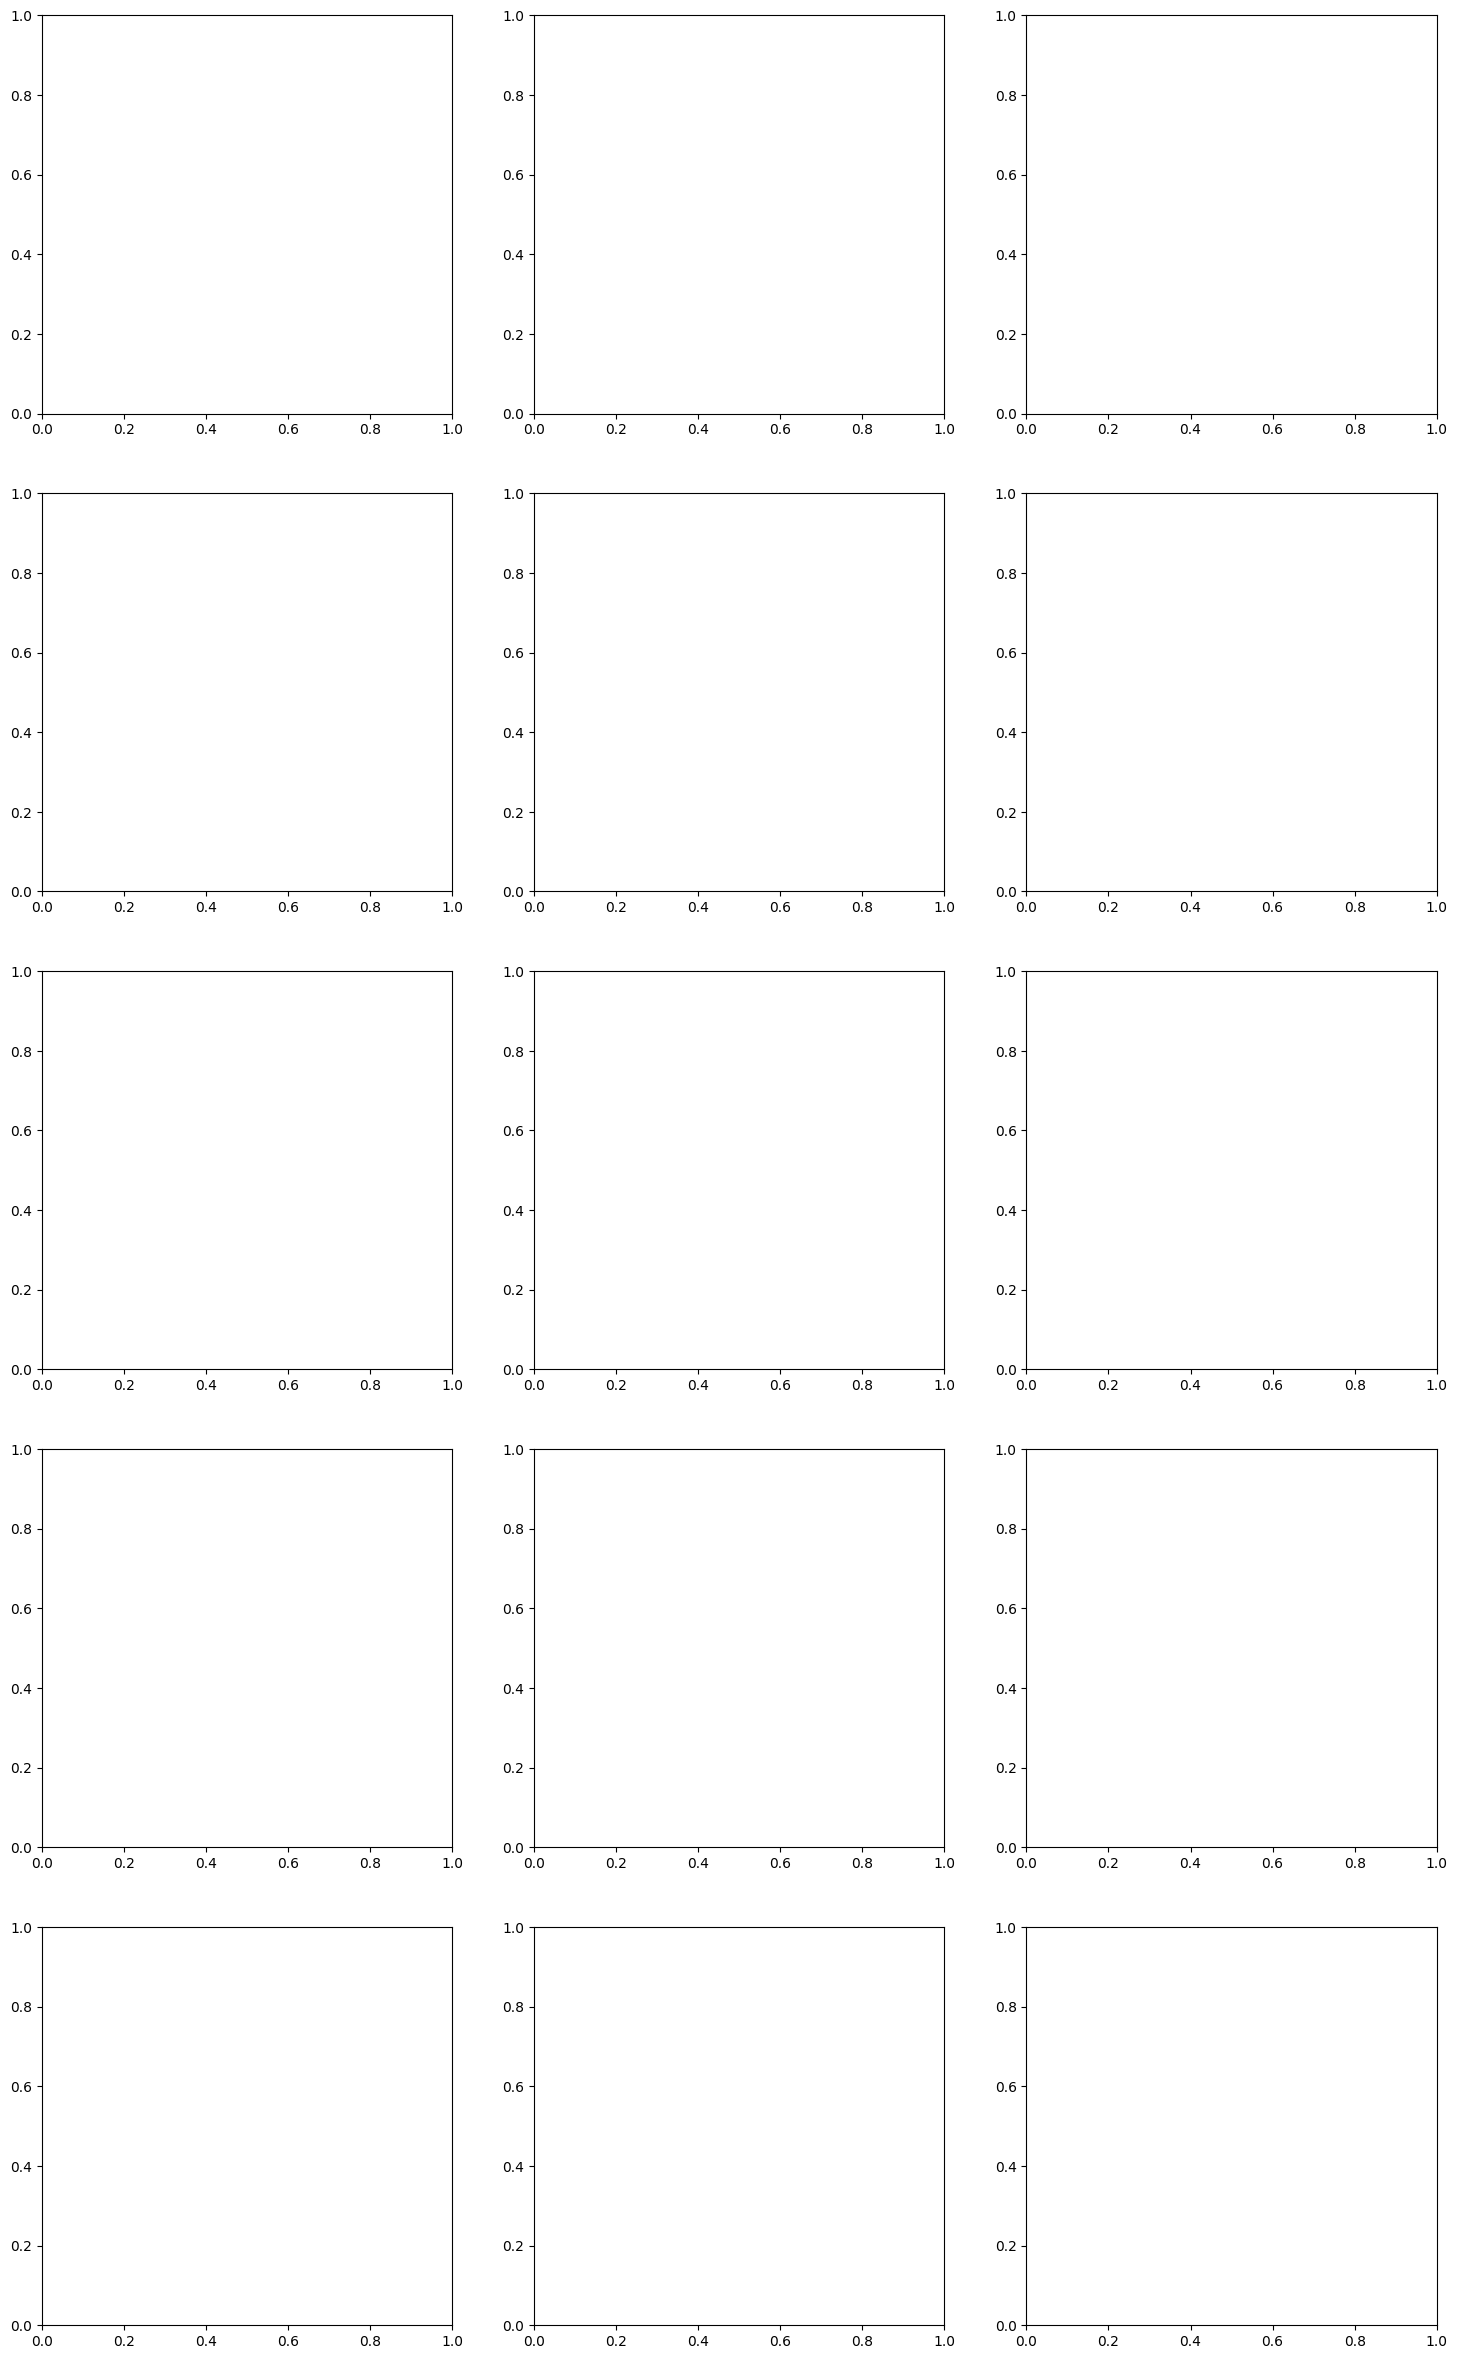

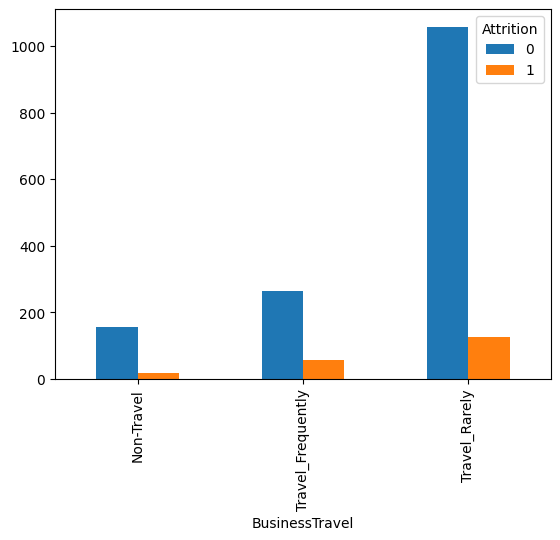

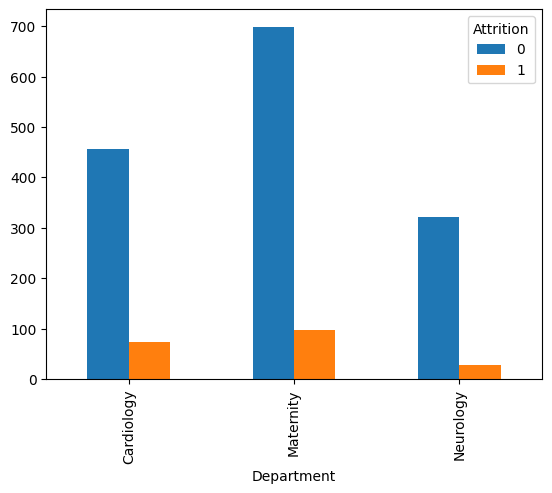

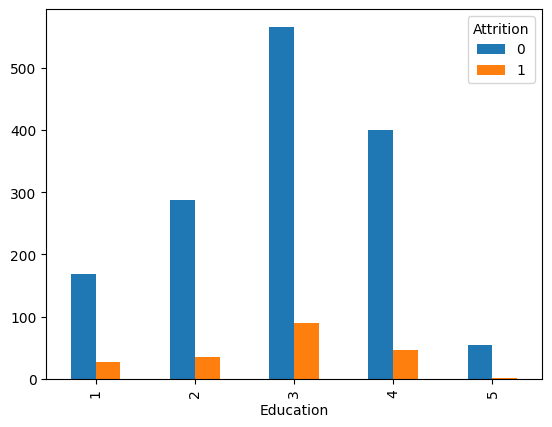

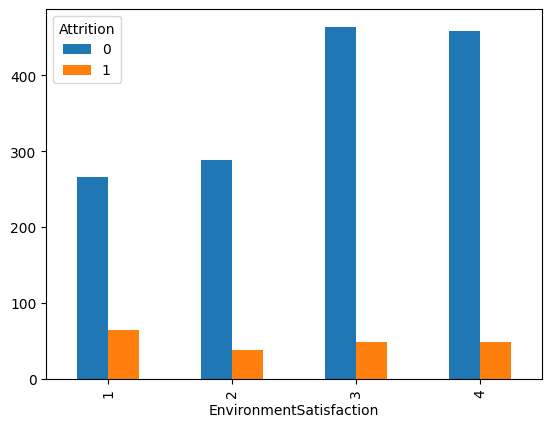

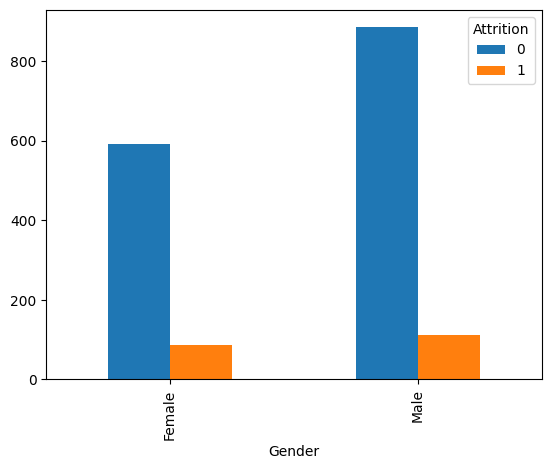

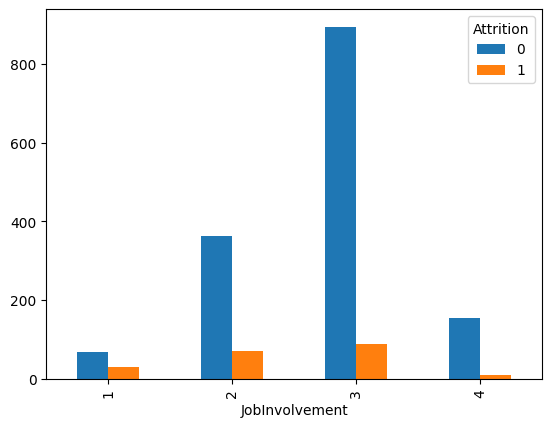

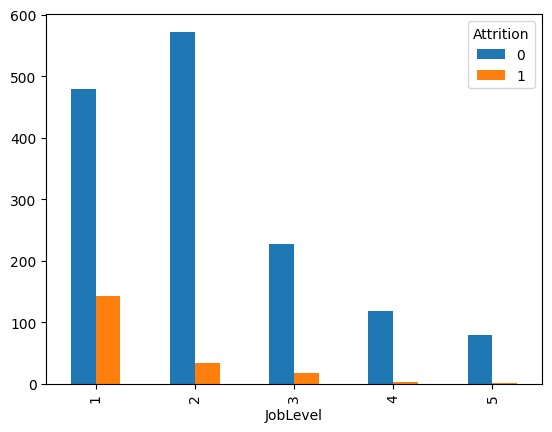

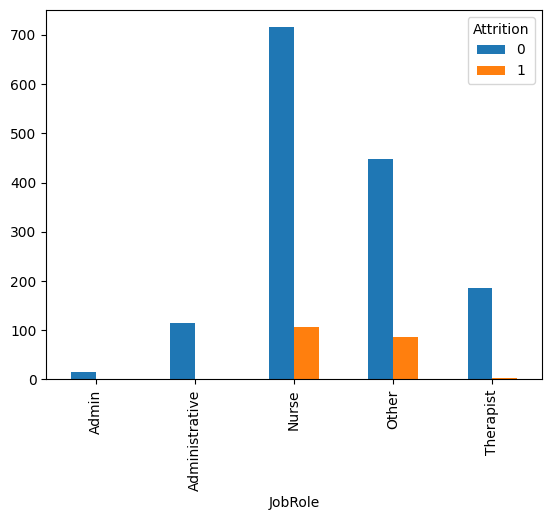

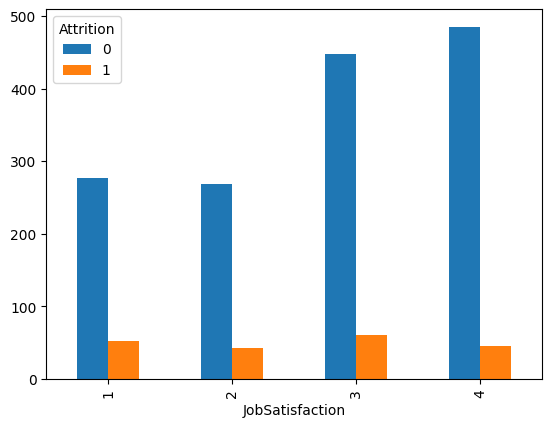

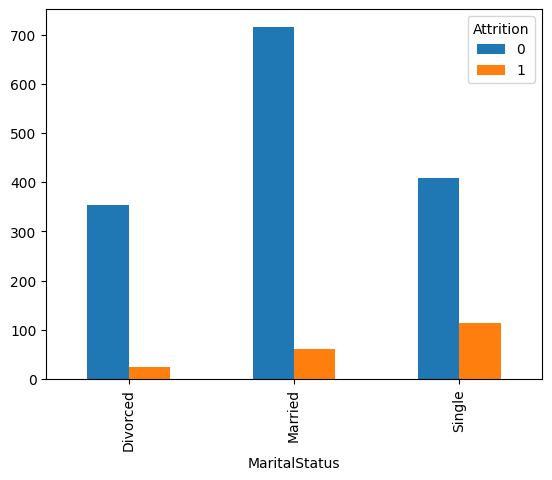

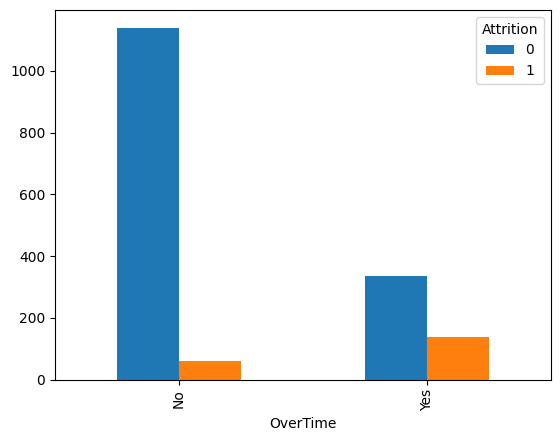

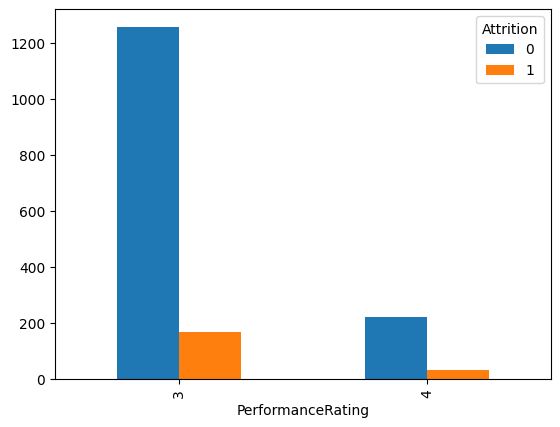

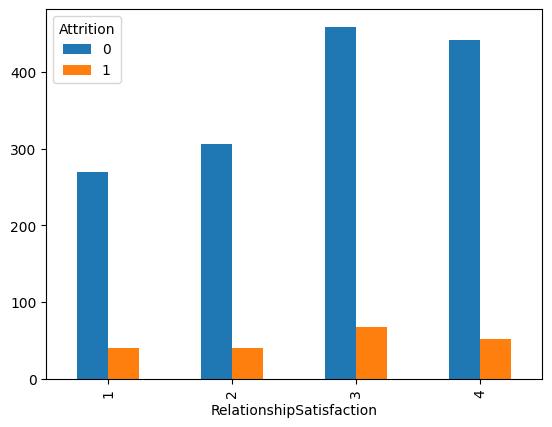

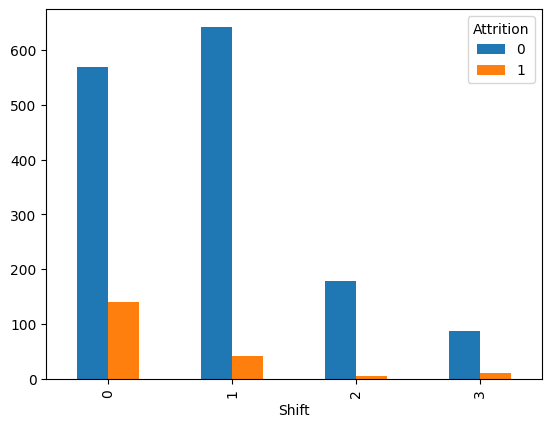

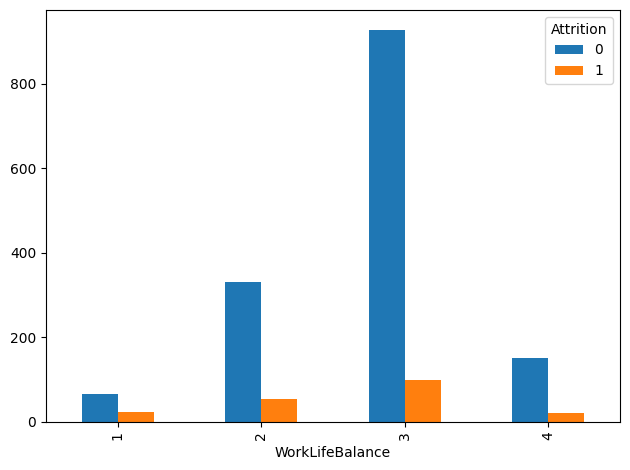

In [ ]:
count=0
collist=[]
for i in df.columns:
    if len(df[i].value_counts())<=5:
        count+=1
        collist.append(i)
total_plots = count-1 
cols = 3
rows = math.ceil(total_plots / cols)

fig_width = cols * 6
fig_height = rows * 6

fig, axes = plt.subplots(
    nrows=rows,
    ncols=cols,
    figsize=(fig_width, fig_height),
    # constrained_layout=True
)
row,col=0,0

for i in df.columns:
    if i != "Attrition" and len(df[i].value_counts())<=5:
        crosstb = pd.crosstab(df[i], df["Attrition"])
        crosstb.plot(kind="bar",ax=axes[row,col])
        axes[row, col].legend()
        col=col+1
        if(col==3):
            row+=1
        col=(col)%cols


plt.tight_layout(w_pad=2)
plt.show()